# DH Intermediate Diagnostics — 20260608 (post-2000, re-fit survivors)

_Cloned from `20260515/dh_intermediate_diagnostics_post2000.ipynb`, repointed at the `20260608_survivors` re-fit run. The manifest is read from the survivor run itself (no `01-preliminary/` in the no-fit-stage pipeline)._

After preliminary screening (`dh_preliminary_diagnostics.ipynb`) the
pool of 73K calibrated DH configs is reduced to ~864 family/exposure
survivors. This notebook works on **storm-level** evidence — the per-row
predictions (`02-evaluate/20260608_survivors/model_predictions/`) that the
preliminary metric set lacked.

Three things become possible at storm-level granularity:

1. **Drop-top-N trimmed calibration** — recompute the obs/pred ratio after
   removing the few mega-events (Nargis 2008, Haiyan 2013, Sidr 2007, etc.)
   that dominate the aggregate. Shows whether the bulk-of-storms behaviour
   is calibrated independently of mega-event handling.
2. **Per-year curves** — Σ pred and Σ obs deaths by year for each config.
   Not a screening metric (the data has no temporal trend; see preliminary
   notebook) but a horror-spotter.
3. **Per-storm scatter** — does the model rank storms correctly within a
   year? Within a basin? Within a SDI bin?

The **threshold decision** falls out of these — different thresholds will
behave differently under drop-top-N, and that's the right basis for picking
which threshold(s) to take forward.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path('..').resolve() / 'reports'))
import _helpers as H


## Setup

Three things to load:
- The survivors `dh_results.parquet` (864 configs × 6 fold_tags).
- The input parquet (1,693 rows: storm × admin location).
- A handle to the `model_predictions/` directory for lazy per-config reads.


In [2]:
ROOT      = Path('/mnt/team/idd/pub/idd_tc_mortality')
EVAL_DATE = '20260608'
SURVIVORS_DIR = ROOT / '02-evaluate' / f'{EVAL_DATE}_survivors'
INPUT_PATH    = ROOT / '00-data' / EVAL_DATE / 'input.parquet'

RESULTS_PATH       = SURVIVORS_DIR / 'dh_results.parquet'
MODEL_PRED_DIR     = SURVIVORS_DIR / 'model_predictions'

obs = pd.read_parquet(INPUT_PATH)
df_all = H.load_and_aggregate(RESULTS_PATH)
print(f'survivors dh_results: {len(df_all):,} configurations')
print(f'input.parquet:        {len(obs):,} storm×admin rows')
print(f'model_predictions dir: {MODEL_PRED_DIR}')
print(f'  parquets present:   {len(list(MODEL_PRED_DIR.glob("*.parquet"))):,}')


survivors dh_results: 846 configurations
input.parquet:        1,903 storm×admin rows
model_predictions dir: /mnt/team/idd/pub/idd_tc_mortality/02-evaluate/20260608_survivors/model_predictions
  parquets present:   4,952


## Apply the asymmetric calibration gate

Reduce the 864 family/exposure survivors to the ~529 that also pass
`full_pred_obs_ratio_oos ∈ [0.1, 1.5]` (asymmetric; see preliminary
notebook §Scope for rationale).


In [3]:
RATIO_BOUNDS = (0.1, 1.5)
ratio = df_all['full_pred_obs_ratio_oos']
calibrated = ratio.between(*RATIO_BOUNDS) & ratio.notna()
df = df_all[calibrated].reset_index(drop=True)
print(f'{len(df):,} of {len(df_all):,} survivors pass '
      f'full_pred_obs_ratio_oos in [{RATIO_BOUNDS[0]}, {RATIO_BOUNDS[1]}]')

# Per-threshold count
print(df['threshold_quantile'].value_counts().sort_index())


589 of 846 survivors pass full_pred_obs_ratio_oos in [0.1, 1.5]
threshold_quantile
0.70     89
0.75    102
0.80     92
0.85     78
0.90    100
0.95    128
Name: count, dtype: int64


## Reconstruct the model_id (`mid`) for each row

`dh_results.parquet` stores spec attributes (family, exposure_mode, cov)
but not the MD5 model_id used as the filename prefix in
`model_predictions/`. Rebuild it once via a lookup against the manifest,
then attach as a `mid` column on `df`.


In [4]:
from idd_tc_mortality.cache import model_id as compute_model_id

MANIFEST_PATH = ROOT / '02-evaluate' / f'{EVAL_DATE}_survivors' / 'manifest.json'
manifest = json.loads(MANIFEST_PATH.read_text())

# Build a lookup: (component, threshold, family, exposure_mode, cov_str) -> full spec dict.
# threshold is None for s1. cov_str is the JSON of covariate_combo with sort_keys=True.
spec_lookup: dict[tuple, dict] = {}
for cid, spec in manifest.items():
    if spec.get('fold_tag', 'is') != 'is':
        continue
    cov_str = json.dumps(spec.get('covariate_combo', {}), sort_keys=True)
    key = (
        spec.get('component'),
        spec.get('threshold_quantile'),  # None for s1
        spec.get('family'),
        spec.get('exposure_mode'),
        cov_str,
    )
    spec_lookup[key] = spec


def _row_to_mid(row: pd.Series) -> str:
    """Look up the 4 component specs for this DH row, compute the model_id hash."""
    q = row['threshold_quantile']
    # cov columns in dh_results are JSON strings already.
    s1 = spec_lookup[('s1',   None, row['s1_family'],   row['s1_exposure_mode'],   row['s1_cov'])]
    s2 = spec_lookup[('s2',   q,    row['s2_family'],   row['s2_exposure_mode'],   row['s2_cov'])]
    bk = spec_lookup[('bulk', q,    row['bulk_family'], row['bulk_exposure_mode'], row['bulk_cov'])]
    tl = spec_lookup[('tail', q,    row['tail_family'], row['tail_exposure_mode'], row['tail_cov'])]
    return compute_model_id(s1, s2, bk, tl)


df['mid'] = df.apply(_row_to_mid, axis=1)
print(f'mid attached. Sample: {df["mid"].head(3).tolist()}')

# Sanity check: at least one mid's files should exist on disk.
test_mid = df['mid'].iloc[0]
is_path  = MODEL_PRED_DIR / f'{test_mid}_insample_predictions.parquet'
print(f'sample IS pred file exists: {is_path.exists()} ({is_path.name})')


mid attached. Sample: ['6514ab8908fe8c5fd0821ff448863e6e', 'bb740d18fc92612dc0294f2c73fca212', '3215fc4d9236947423644966269581da']
sample IS pred file exists: True (6514ab8908fe8c5fd0821ff448863e6e_insample_predictions.parquet)


## Per-config prediction loader

Each calibrated config has 6 per-row prediction parquets:
- 1 IS (`<mid>_insample_predictions.parquet`)
- 5 OOS seeds (`<mid>_oos_seed{0..4}_predictions.parquet`)

The helper below loads any one of them. We need `mid` (model_id) — the
column in `df` that identifies the config.


In [5]:
# What's the config-id column?
print([c for c in df.columns if 'id' in c.lower() or c in ('mid','model_id')])
print(df.head(3))


['mid']
   threshold_quantile s1_family s1_exposure_mode  \
0                 0.7     logit             free   
1                 0.7     logit             free   
2                 0.7     logit             free   

                                              s1_cov s2_family  \
0  {"basin": false, "is_island": false, "sdi": fa...     logit   
1  {"basin": false, "is_island": false, "sdi": fa...     logit   
2  {"basin": false, "is_island": false, "sdi": fa...     logit   

  s2_exposure_mode                                             s2_cov  \
0             free  {"basin": false, "is_island": false, "sdi": fa...   
1             free  {"basin": false, "is_island": false, "sdi": fa...   
2             free  {"basin": false, "is_island": false, "sdi": fa...   

    bulk_family bulk_exposure_mode  \
0  scaled_logit               free   
1  scaled_logit               free   
2  scaled_logit               free   

                                            bulk_cov  ...  \
0  {"basin"

In [6]:
# Helper: load IS predictions for a config.
# Note: model_predictions parquets do NOT carry storm_id / year / location_id.
# Those live in input.parquet; the predictions are row-aligned to it.
# The loaders join by position so every returned frame carries the input
# metadata (storm_id, year, location_id, basin, etc.) alongside predicted_rate.

def _join_input(pred_df: pd.DataFrame) -> pd.DataFrame:
    """Attach input.parquet's metadata columns to a per-row prediction frame."""
    if len(pred_df) != len(obs):
        raise ValueError(
            f'prediction row count {len(pred_df)} != input row count {len(obs)}'
        )
    out = obs.copy()
    out['predicted_rate'] = pred_df['predicted_rate'].values
    # Pass through extra cols the pred frame carries (heldout_fold_tag for OOS).
    for col in ('heldout_fold_tag', 'threshold_rate', 'fold_tag'):
        if col in pred_df.columns:
            out[col] = pred_df[col].values
    return out


def load_is_pred(mid: str) -> pd.DataFrame:
    p = MODEL_PRED_DIR / f'{mid}_insample_predictions.parquet'
    return _join_input(pd.read_parquet(p))


def load_oos_pred(mid: str) -> pd.DataFrame:
    """Load all 5 OOS-seed predictions, joined to input metadata, with `seed` col."""
    frames = []
    for seed in range(5):
        p = MODEL_PRED_DIR / f'{mid}_oos_seed{seed}_predictions.parquet'
        if not p.exists():
            continue
        joined = _join_input(pd.read_parquet(p))
        joined['seed'] = seed
        frames.append(joined)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


## Drop-top-N trimmed calibration ratio

For every calibrated config, compute the OOS aggregate ratio after dropping
the top-N storms by observed deaths. Sweep N = 0, 1, 3, 5, 10 to see how
the calibration story changes as mega-events are removed. Configs that look
calibrated only because they got Nargis right (under-prediction by 2×, say,
of the 138K Nargis deaths) will drop sharply in the trimmed ratio.


In [7]:
def trimmed_full_ratio_is(mid: str, drop_top_n: int) -> float:
    is_df = load_is_pred(mid)
    if is_df.empty:
        return float('nan')
    is_df['pred_deaths'] = is_df['predicted_rate'] * is_df['exposed']
    per_storm = (is_df.groupby('storm_id', as_index=False)
        .agg(obs=('deaths', 'sum'), pred=('pred_deaths', 'sum'))
        .sort_values('obs', ascending=False))
    keep = per_storm.iloc[drop_top_n:]
    denom = keep['obs'].sum()
    return float(keep['pred'].sum() / denom) if denom > 0 else float('nan')


def trimmed_full_ratio_oos(mid: str, drop_top_n: int) -> dict:
    """Returns dict of per-seed and mean trimmed ratios. NaN-safe."""
    oos = load_oos_pred(mid)
    if oos.empty or 'predicted_rate' not in oos.columns:
        return {'mean': float('nan'), 'per_seed': []}

    out = {'per_seed': []}
    oos['pred_deaths'] = oos['predicted_rate'] * oos['exposed']
    for seed, sdf in oos.groupby('seed'):
        per_storm = (sdf
            .groupby('storm_id', as_index=False)
            .agg(obs=('deaths', 'sum'), pred=('pred_deaths', 'sum'))
            .sort_values('obs', ascending=False))
        keep = per_storm.iloc[drop_top_n:]  # drop top-N by observed
        denom = keep['obs'].sum()
        ratio = float(keep['pred'].sum() / denom) if denom > 0 else float('nan')
        out['per_seed'].append(ratio)
    out['mean'] = float(np.nanmean(out['per_seed']))
    out['median'] = float(np.nanmedian(out['per_seed'])) 
    return out


# Sweep over a few N values, on a tractable sample first.
N_SWEEP = [0, 5, 10, 25]
# NOTE: full sweep over all 529 calibrated configs is ~10 min of NFS reads.
# Sample 100 first to sanity-check the cell speed, then expand.
sample = df
records = []


for _, row in sample.iterrows():
    mid = row['mid']
    for n in N_SWEEP:
        r_oos = trimmed_full_ratio_oos(mid, drop_top_n=n)
        r_is  = trimmed_full_ratio_is(mid, drop_top_n=n)
        records.append({
            'mid': mid,
            'drop_top_n': n,
            'ratio_mean':   r_oos['mean'],
            'ratio_median': r_oos['median'],
            'ratio_is':     r_is,
        })




In [8]:
recs = pd.DataFrame(records)

trim_df_mean   = recs.pivot(index='mid', columns='drop_top_n', values='ratio_mean')
trim_df_median = recs.pivot(index='mid', columns='drop_top_n', values='ratio_median')
trim_df_is     = recs.pivot(index='mid', columns='drop_top_n', values='ratio_is')

trim_df_mean.columns   = [f'trim_n={n}_oos_mean'   for n in trim_df_mean.columns]
trim_df_median.columns = [f'trim_n={n}_oos_median' for n in trim_df_median.columns]
trim_df_is.columns     = [f'trim_n={n}_is'         for n in trim_df_is.columns]

trim_df = trim_df_median  # canonical: matches the median-aggregation of the screening gate


**What to look for:** configs whose `trim_n=0` is near 1 but `trim_n=5` is
far from 1 (or vice versa) are exposed as either Nargis-only or bulk-only
calibrated. The configs you want are the ones where the trimmed ratio stays
near 1 across the N sweep — those are calibrated *both* in the mega-events
*and* in the bulk.


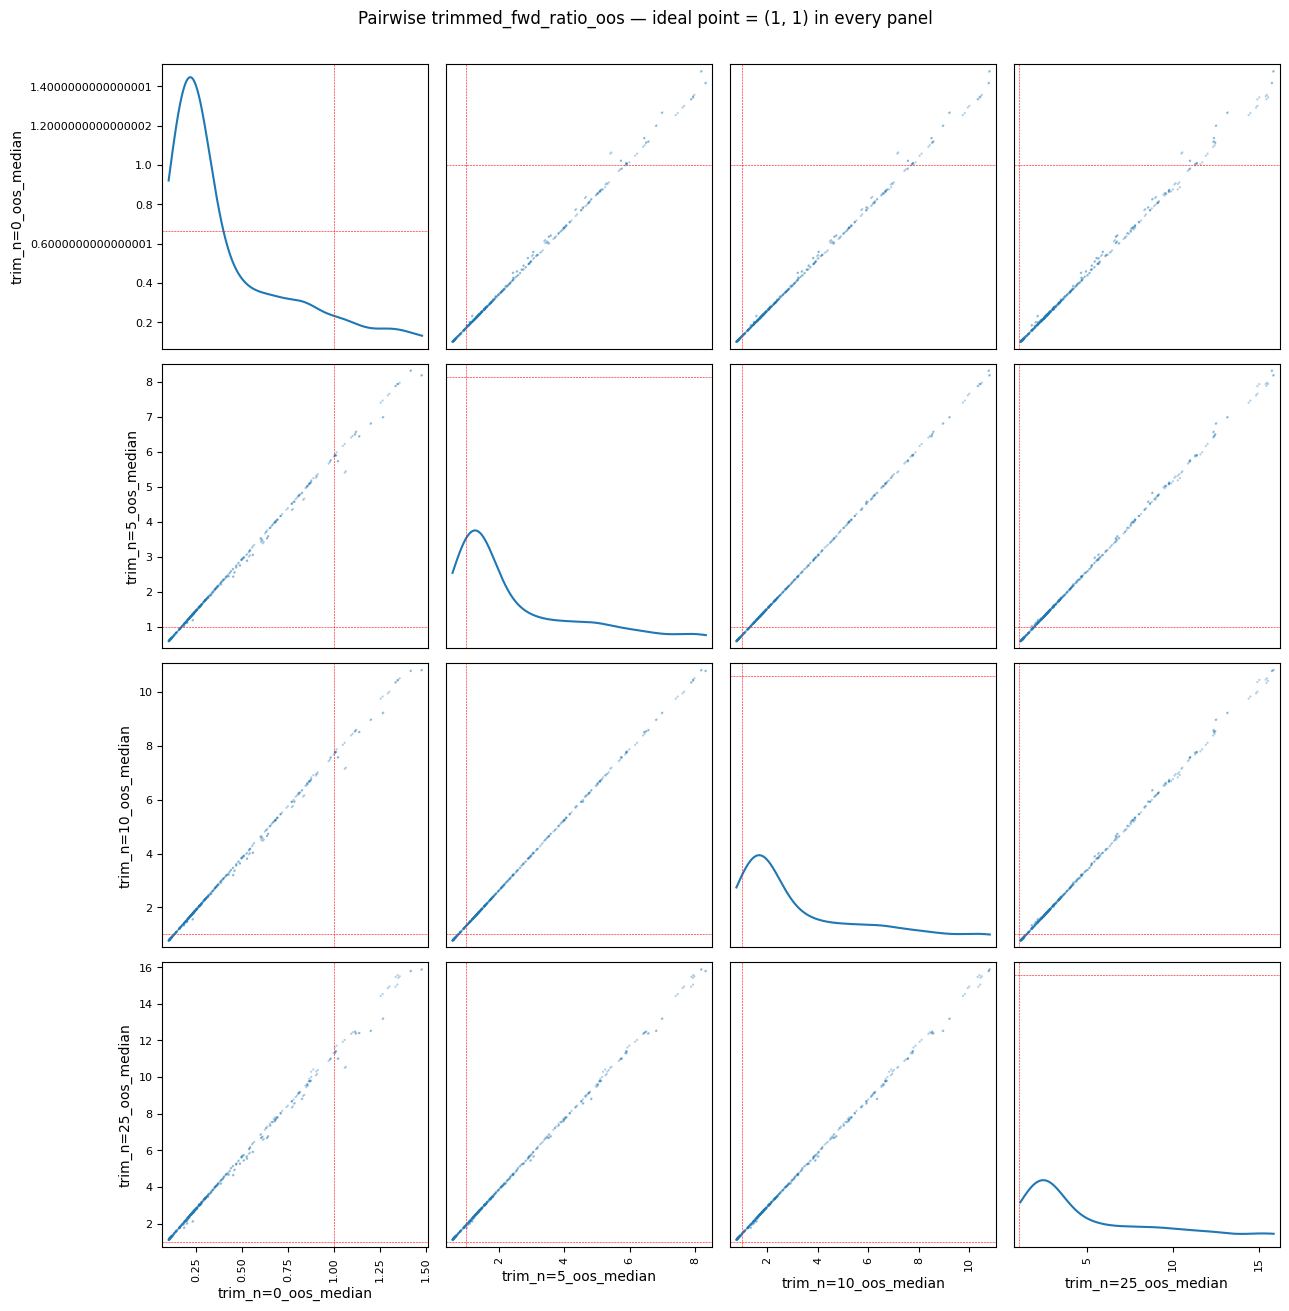

In [9]:
# Pairwise scatter matrix on log scale: do the SAME configs stay near 1 across N?
# Ideal point in every panel is (1,1) (i.e. ratio = 1).
# A config that is well-calibrated regardless of how many big storms we drop
# appears as a point near (1, 1) in every cell.

from pandas.plotting import scatter_matrix

axes = scatter_matrix(trim_df, figsize=(13, 13), diagonal='kde', alpha=0.35, s=10)
# Reference lines at ratio = 1 in every panel.
for ax_row in axes:
    for ax in ax_row:
        ax.axhline(1, color='red', linestyle='--', linewidth=0.4)
        ax.axvline(1, color='red', linestyle='--', linewidth=0.4)
plt.suptitle('Pairwise trimmed_fwd_ratio_oos — ideal point = (1, 1) in every panel', y=1.005)
plt.tight_layout()
plt.show()


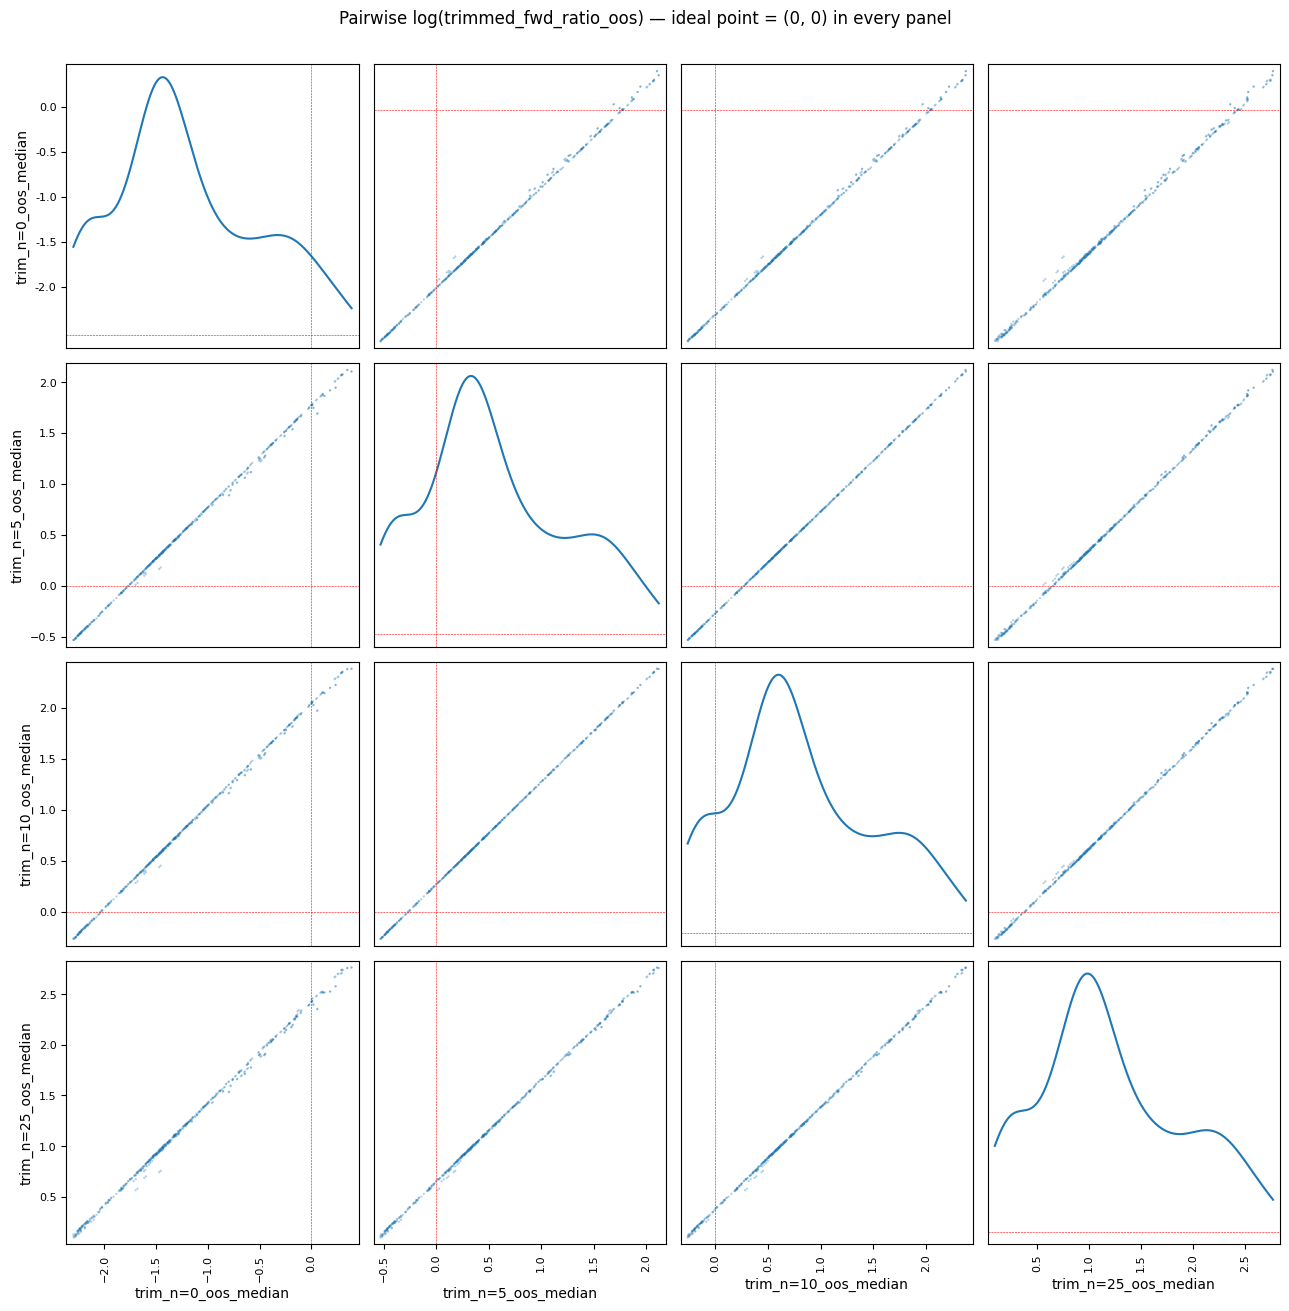

In [10]:
# Pairwise scatter matrix on log scale: do the SAME configs stay near 1 across N?
# Ideal point in every panel is (0, 0) (i.e. log(ratio) = 0 ↔ ratio = 1).
# A config that is well-calibrated regardless of how many big storms we drop
# appears as a point near (0, 0) in every cell.

from pandas.plotting import scatter_matrix

log_trim = (trim_df.replace([np.inf, -np.inf], np.nan)
                   .clip(lower=1e-2, upper=1e3)
                   .apply(np.log))

axes = scatter_matrix(log_trim, figsize=(13, 13), diagonal='kde', alpha=0.35, s=10)
# Reference lines at log(1) = 0 in every panel.
for ax_row in axes:
    for ax in ax_row:
        ax.axhline(0, color='red', linestyle='--', linewidth=0.4)
        ax.axvline(0, color='red', linestyle='--', linewidth=0.4)
plt.suptitle('Pairwise log(trimmed_fwd_ratio_oos) — ideal point = (0, 0) in every panel', y=1.005)
plt.tight_layout()
plt.show()


In [11]:
trim_df_is[trim_df_is['trim_n=5_is'] < 3.0]

,trim_n=0_is,trim_n=5_is,trim_n=10_is,trim_n=25_is
mid,,,,
00150380ce9a48731d03a2032a574591,0.490576,2.748720,3.621924,5.262511
001f260c558c92373a8a6c87f9831d69,0.245603,1.442625,1.891441,2.773260
005531cf104523822023c160f41baca9,0.108414,0.636348,0.834070,1.219572
02605eba3b055b80975a1c4e7a2cbb60,0.207535,1.220461,1.597603,2.354802
026d785cff596a2cdf7b7231b1a946f6,0.187083,1.089925,1.423251,2.056796
...,...,...,...,...
fa9c6d11b2a17136eaa6ce5a84fbe30e,0.230992,1.354842,1.768877,2.597565
fb44cbf05a046559bb04ec9090cb9230,0.233105,1.352315,1.766869,2.565678
fca63240bccc3f1caa88368a86d15944,0.153403,0.891612,1.165721,1.691916


In [12]:
trim_df_median['trim_n=5_oos_median'].describe()

count    589.000000
mean       2.251625
std        1.738291
min        0.587907
25%        1.129302
50%        1.554867
75%        2.907674
max        8.326917
Name: trim_n=5_oos_median, dtype: float64

In [13]:
lower_trim = 0.2
upper_trim = 2.0
second_trim_df = trim_df_median.copy()
second_trim_df = second_trim_df[(second_trim_df['trim_n=5_oos_median'] < upper_trim) & (second_trim_df['trim_n=5_oos_median'] > lower_trim)]
print(df.loc[df['mid'].isin(second_trim_df.index), 'threshold_quantile'].value_counts().sort_index())
second_trim_df = second_trim_df[(second_trim_df['trim_n=10_oos_median'] < upper_trim) & (second_trim_df['trim_n=10_oos_median'] > lower_trim)]
print(df.loc[df['mid'].isin(second_trim_df.index), 'threshold_quantile'].value_counts().sort_index())
second_trim_df = second_trim_df[(second_trim_df['trim_n=25_oos_median'] < upper_trim) & (second_trim_df['trim_n=25_oos_median'] > lower_trim)]
print(df.loc[df['mid'].isin(second_trim_df.index), 'threshold_quantile'].value_counts().sort_index())

threshold_quantile
0.70    59
0.75    64
0.80    59
0.85    49
0.90    50
0.95    96
Name: count, dtype: int64
threshold_quantile
0.70    51
0.75    50
0.80    44
0.85    46
0.90    38
0.95    61
Name: count, dtype: int64
threshold_quantile
0.70    26
0.75    27
0.80    24
0.85    16
0.90    18
0.95    17
Name: count, dtype: int64


In [14]:
lower_trim = 0.25
upper_trim = 1.2
third_trim_df = trim_df_is.copy()
# only include those rows that survived second trim on the median metric
third_trim_df = third_trim_df[third_trim_df.index.isin(second_trim_df.index)]
third_trim_df = third_trim_df[(third_trim_df['trim_n=5_is'] < upper_trim) & (third_trim_df['trim_n=5_is'] > lower_trim)]
print(df.loc[df['mid'].isin(third_trim_df.index), 'threshold_quantile'].value_counts().sort_index())
third_trim_df = third_trim_df[(third_trim_df['trim_n=10_is'] < upper_trim) & (third_trim_df['trim_n=10_is'] > lower_trim)]
print(df.loc[df['mid'].isin(third_trim_df.index), 'threshold_quantile'].value_counts().sort_index())
third_trim_df = third_trim_df[(third_trim_df['trim_n=25_is'] < upper_trim) & (third_trim_df['trim_n=25_is'] > lower_trim)]
print(df.loc[df['mid'].isin(third_trim_df.index), 'threshold_quantile'].value_counts().sort_index())

threshold_quantile
0.70    26
0.75    27
0.80    24
0.85    16
0.90    18
0.95    17
Name: count, dtype: int64
threshold_quantile
0.70    24
0.75    24
0.80    24
0.85    12
0.90    18
0.95    11
Name: count, dtype: int64
threshold_quantile
0.70    11
0.75    18
0.80     7
0.85     5
0.90     2
Name: count, dtype: int64


In [15]:
# Best models: rank by maximum |log(ratio)| across all N values.
clean = third_trim_df.replace([np.inf, -np.inf], np.nan).dropna()
log_dev = np.abs(np.log(clean))
clean = clean.assign(max_log_dev=log_dev.max(axis=1),
                     mean_log_dev=log_dev.mean(axis=1))

best = clean.sort_values('max_log_dev')

# NEW: join in the OOS-median trim values by mid (index).
best = best.join(trim_df_median, how='left')

print()
print(best.round(3).to_string())

best_mids = best.index.tolist()
attrs_cols = ['mid', 'threshold_quantile',
              's1_family', 's1_exposure_mode',
              's2_family', 's2_exposure_mode',
              'bulk_family', 'bulk_exposure_mode',
              'tail_family', 'tail_exposure_mode']
best_attrs = (df[df['mid'].isin(best_mids)][attrs_cols]
              .merge(best.reset_index(), on='mid')
              .sort_values('max_log_dev')
              .reset_index(drop=True))

print()
print('Attributes of those top configs (IS + OOS-median trim values):')
print(best_attrs[['mid', 'threshold_quantile',
                  'bulk_family', 'bulk_exposure_mode',
                  'tail_family', 'tail_exposure_mode',
                  'trim_n=0_is', 'trim_n=5_is', 'trim_n=10_is', 'trim_n=25_is',
                  'trim_n=0_oos_median', 'trim_n=5_oos_median',
                  'trim_n=10_oos_median', 'trim_n=25_oos_median',
                  'max_log_dev']].to_string(index=False))



                                  trim_n=0_is  trim_n=5_is  trim_n=10_is  trim_n=25_is  max_log_dev  mean_log_dev  trim_n=0_oos_median  trim_n=5_oos_median  trim_n=10_oos_median  trim_n=25_oos_median
mid                                                                                                                                                                                                    
1f619974b91550429d9a6303b4fe9145        0.109        0.628         0.819         1.182        2.218         0.762                0.111                0.646                 0.844                 1.220
b906371f8812094b3f47c8a814fee399        0.107        0.625         0.820         1.200        2.239         0.772                0.111                0.650                 0.852                 1.244
7300d58b9485793c46196aa5623bd511        0.106        0.625         0.819         1.199        2.240         0.773                0.112                0.656                 0.860                 1.259

In [16]:
# IS / OOS ratio per N. Close to 1 = IS and OOS agree = good generalization.
# Far from 1 in either direction = overfitting (IS << OOS would be very weird here;
# IS > OOS is the over-fit-on-training direction).
for n in [0, 5, 10, 25]:
    best[f'is_oos_ratio_n={n}'] = best[f'trim_n={n}_is'] / best[f'trim_n={n}_oos_median']

# Also rank by IS-OOS divergence: configs that stay near 1 across all N are
# the ones whose IS calibration carries to OOS without surprises.
ratio_cols = [f'is_oos_ratio_n={n}' for n in [0, 5, 10, 25]]
best['is_oos_max_log_dev']  = np.abs(np.log(best[ratio_cols])).max(axis=1)
best['is_oos_mean_log_dev'] = np.abs(np.log(best[ratio_cols])).mean(axis=1)



In [17]:
for n in [0, 5, 10, 25]:
    best_attrs[f'is_oos_ratio_n={n}'] = (
        best_attrs[f'trim_n={n}_is'] / best_attrs[f'trim_n={n}_oos_median']
    )

ratio_cols = [f'is_oos_ratio_n={n}' for n in [0, 5, 10, 25]]
best_attrs['is_oos_max_log_dev']  = np.abs(np.log(best_attrs[ratio_cols])).max(axis=1)
best_attrs['is_oos_mean_log_dev'] = np.abs(np.log(best_attrs[ratio_cols])).mean(axis=1)



In [19]:

print(best_attrs[['mid', 'threshold_quantile',
                  'tail_family', 'tail_exposure_mode',
                  'is_oos_ratio_n=0', 'is_oos_ratio_n=5',
                  'is_oos_ratio_n=10', 'is_oos_ratio_n=25',
                  'is_oos_max_log_dev',
                  'max_log_dev']].round(3)
                .sort_values('is_oos_ratio_n=25')
                .to_string(index=False))


                             mid  threshold_quantile  tail_family tail_exposure_mode  is_oos_ratio_n=0  is_oos_ratio_n=5  is_oos_ratio_n=10  is_oos_ratio_n=25  is_oos_max_log_dev  max_log_dev
ace34efcce1392a62d5d6b57b25e6882                0.85          gpd             weight             0.701             0.702              0.701              0.698               0.359        2.525
b11a6534167ef1992a7d59560d4b31b7                0.85          gpd             weight             0.707             0.708              0.707              0.704               0.350        2.489
f00f12183e27b7b3eeaab31c162eaf85                0.70          gpd        free+weight             0.790             0.787              0.784              0.805               0.244        2.360
8ebe56b8898f75029612d3a700c1c1ff                0.70          gpd        free+weight             0.795             0.791              0.787              0.807               0.239        2.333
b0f90fd09f2012129f3b5ddacc1a10e9        

In [ ]:
# STOP HERE
# CHOICE: Decision: threshold ={0.70, 0.85}, tail ∈ {gpd, log_logistic, weibull}. 